In [115]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Operator
from qiskit_dynamics import Solver
from qiskit_dynamics.pulse import InstructionToSignals
import qiskit.pulse as pulse
import warnings
warnings.filterwarnings('ignore')
from scipy.optimize import minimize_scalar, minimize
import sympy as sym



In [151]:
#construct a Gaussian square pulse
def lifted_gaussian(
    t: sym.Symbol,
    center,
    t_zero,
    sigma,
) -> sym.Expr:
    t_shifted = (t - center).expand()
    t_offset = (t_zero - center).expand()

    gauss = sym.exp(-((t_shifted / sigma) ** 2) / 2)
    offset = sym.exp(-((t_offset / sigma) ** 2) / 2)

    return (gauss - offset) / (1 - offset)


def gaussian_square_generated_by_pulse(params):

    
    _t, _duration, _amp, _sigma, _width, _angle = sym.symbols(
        "t, duration, amp, sigma, width, angle"
    )
    _center = _duration / 2

    _sq_t0 = _center - _width / 2
    _sq_t1 = _center + _width / 2

    _gaussian_ledge = lifted_gaussian(_t, _sq_t0, -1, _sigma)
    _gaussian_redge = lifted_gaussian(_t, _sq_t1, _duration + 1, _sigma)

    envelope_expr = (
        _amp
        * sym.exp(sym.I * _angle)
        * sym.Piecewise(
            (_gaussian_ledge, _t <= _sq_t0), (_gaussian_redge, _t >= _sq_t1), (1, True)
        )
    )

    # we need to set disable_validation True to enable jax-jitting.
    pulse.ScalableSymbolicPulse.disable_validation = True
    parameters={"sigma": params['sigma'], "width": params['width']}
    print(parameters)
    return pulse.ScalableSymbolicPulse(
            pulse_type="GaussianSquare",
            duration=230,
            amp=1,
            angle=0,
            parameters={"sigma": params['sigma'], "width": params['width']},
            envelope=envelope_expr,
            constraints=sym.And(_sigma > 0, _width >= 0, _duration >= _width),
            valid_amp_conditions=sym.Abs(_amp) <= 1.0,
        )


In [152]:
def rased_cosine_generated_by_pulse(params):

    
    _t, _duration, _amp = sym.symbols(
        "t, duration, amp"
    )
    envelope_expr = _amp * 0.5 * (1 - sym.cos(2 * sym.pi * _t / _duration))
  #  print(f'duration {params["duration"]}')
    return pulse.ScalableSymbolicPulse(
        pulse_type="RaisedCosine",
        duration=params["duration"],
        amp=params["amp"],
        angle=params['angle'],
        envelope=envelope_expr,
  
        constraints=_duration > 0,
        valid_amp_conditions=sym.Abs(_amp) <= 1.0,
    )



In [153]:
def build_gs_pulse(params):
    instance = gaussian_square_generated_by_pulse(params)
    with pulse.build() as Xp:
        pulse.play(instance, pulse.DriveChannel(0))
    return Xp, instance

def convert_into_signal(Xp):
    converter = InstructionToSignals(dt, carriers={"d0": v})
    signal = converter.get_signals(Xp)
    return signal



def build_rc_pulse(params):
    instance=rased_cosine_generated_by_pulse(params)
    with pulse.build() as Xp:
        pulse.play(instance, pulse.DriveChannel(0))
    return Xp, instance



def build_pulse(pulse_type, params):
    if pulse_type=='GaussianSquare':
        return build_gs_pulse(params)
    elif pulse_type=='RasedCosine':
        return build_rc_pulse(params)
    else:
        raise Warning('I am currently working only with GaussianSquare and RaiseCosine!')


X_op = Operator.from_label('X').data
print(f'σx: {X_op}') 
Y_op=Operator.from_label('Y').data
print(f'σy: {Y_op}')


def fidelity(U):
    return np.abs(np.trace(X_op.conj().T @ U))**2 / 4


σx: [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
σy: [[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]


In [163]:


%matplotlib inline
dt=0.222
v=5.0
r=0.02

static_hamiltonian = 2 * np.pi * v * Operator.from_label('Z') / 2    #H0(t)=2pv*Z/2 
drive_term = 2 * np.pi * r * Operator.from_label('X') / 2            #Hd(t)=2prs(t)*X/2
hamiltonian_solver = Solver(
    static_hamiltonian=static_hamiltonian,
    hamiltonian_operators=[drive_term],
    hamiltonian_channels=["d0"],
    channel_carrier_freqs={"d0": v},
    rotating_frame=static_hamiltonian,
    dt=dt,
)

class objective_wrap():
    def __init__(self, pulse_t, optimize_param,fixed_param):
        self.pulse_t=pulse_t
        self.fixed_param=fixed_param
        self.optimize_param=optimize_param
    def objective(self, x):
        all_params=self.fixed_param.copy()
        if len(self.optimize_param)==1:
            all_params[next(iter(self.optimize_param))]=x
            
        else:
            for name,val in zip(self.optimize_param,x):
                all_params[name]=val
                
        if self.pulse_t=='RasedCosine' and 'width' in self.optimize_param:
           # print('Cosine and optimizing width')
            all_params['duration'] = max(1, int(round(all_params['width'])))
       
        Xp,instance=build_pulse(self.pulse_t,all_params)
        #Xp, instance=build_rc_pulse(all_params)
        signals=convert_into_signal(Xp)
        result = hamiltonian_solver.solve(
            y0=np.eye(2, dtype=complex),
            t_span=[0, instance.duration * dt],
            signals=[signals],
            atol=1e-8,
            rtol=1e-8
        )
        return 1. - fidelity(result[0].y[-1])
    




    

    #gaussian_square_generated_by_pulse(all_params).draw()
   
  


optimize_param={'width' : 10.0}
fixed_param={'amp':1, 'duration':230, 'angle':12, 'phase':0, 'sigma':10.0}

obj=objective_wrap('RasedCosine', optimize_param, fixed_param)
if len(optimize_param)==1:
    res = minimize_scalar(
        obj.objective,
        bounds=(0.0, 500.0),   # width must be <= duration
        method="bounded",
        options={"xatol": 1e-2}
    )
    optimal_params = res.x
    optimal_fidelity = 1.0 - res.fun
    
    print("Optimal parameter:", optimal_params)
    print("Optimal fidelity:", optimal_fidelity)

    print(res.message)
    print('Number of function evaluations: ' + str(res.nfev))
    print('Function value: ' + str(res.fun))
else:
    res=minimize(obj.objective,
                 x0=[40.0, 8.0], method="Nelder-Mead")
    optimal_params = {}
    for i, name in enumerate(optimize_param):
        optimal_params[name] = res.x[i]
    print(f'Optimal params: {optimal_params}')
    optimal_fidelity = 1.0 - res.fun
    print("Optimal fidelity:", optimal_fidelity)
    print(res.message)
    print('Number of function evaluations: ' + str(res.nfev))
    print('Function value: ' + str(res.fun))

Optimal parameter: 450.1025830912204
Optimal fidelity: 0.999997404913154
Solution found.
Number of function evaluations: 14
Function value: 2.5950868459689858e-06


Initial fidelity: 0.0012115191225724464
Final fidelity: 0.999997404913154


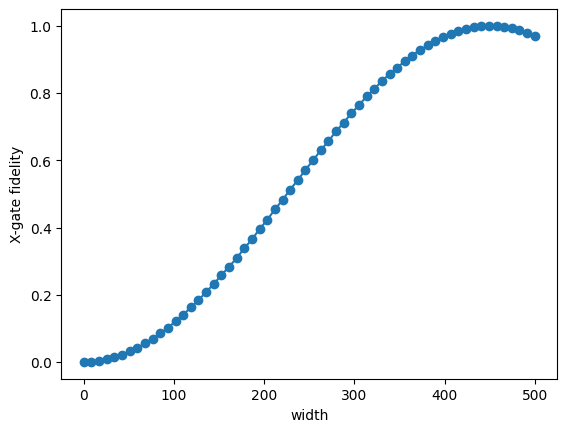

In [164]:
print("Initial fidelity:", 1.0 - obj.objective(10.0))
print("Final fidelity:", 1.0 - obj.objective(optimal_params))



widths = np.linspace(0, 500, 60)
fids = [1 - obj.objective(w) for w in widths]

plt.figure()
plt.plot(widths, fids, "o-")
plt.xlabel("width")
plt.ylabel("X-gate fidelity")
plt.show()



INitial parameters: {'width': 10.0, 'amp': 1, 'duration': 230, 'angle': 12, 'phase': 0, 'sigma': 10.0}
Optimized parameters {'amp': 1, 'duration': 450, 'angle': 12, 'phase': 0, 'sigma': 10.0}


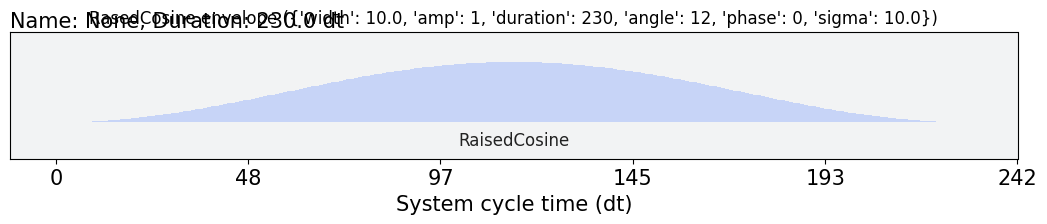

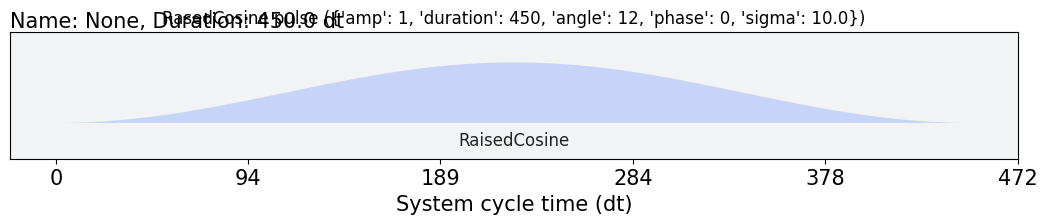

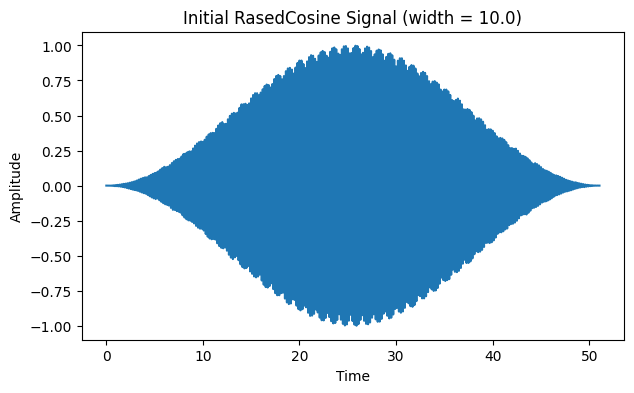

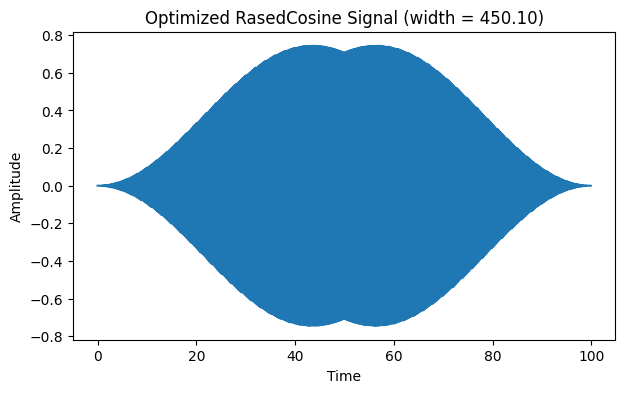

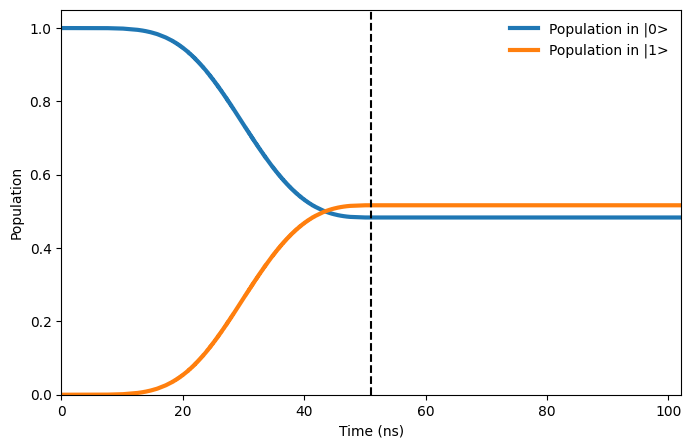

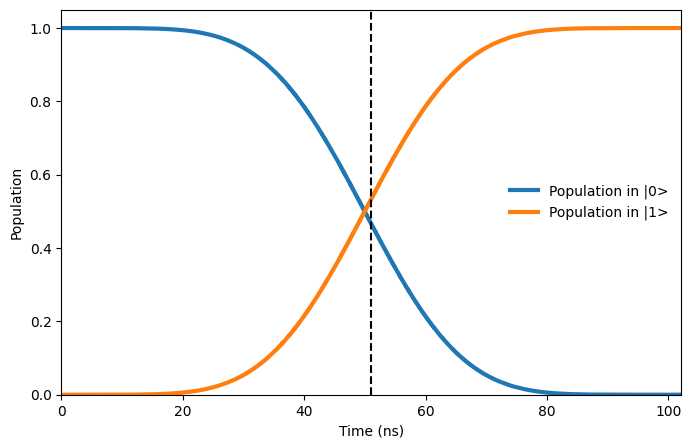

In [171]:
%matplotlib inline
initial_params=optimize_param | fixed_param
print(f'INitial parameters: {initial_params}')
optimized_paramms=fixed_param.copy()
if not isinstance(optimal_params, dict):
    optimized_paramms['duration']=int(optimal_params)
else:
    optimized_paramms=optimal_param | fixed_param
print(f'Optimized parameters {optimized_paramms}')
def plot_env_initial_optimized():
    initial_pulse=rased_cosine_generated_by_pulse(initial_params).draw()
    plt.gca().set_title(f"RasedCosine envelope ({initial_params})")
    plt.show()
    
    
    opt_pulse=rased_cosine_generated_by_pulse(optimized_paramms).draw()
    plt.title(f"RasedCosine pulse ({optimized_paramms})")
    plt.show()



def plot_signal_inital_optimized():
    
    Xp, instance=build_rc_pulse(initial_params)
    signals=convert_into_signal(Xp)
    fig, ax = plt.subplots(figsize=(7,4))
    signals[0].draw(0, instance.duration * dt, 2000, axis=ax)
    ax.set_title(f"Initial RasedCosine Signal (width = 10.0)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    plt.show()


    Xp_opt, instance_opt=build_rc_pulse(optimized_paramms)
    signals_opt=convert_into_signal(Xp_opt)
    fig, ax = plt.subplots(figsize=(7,4))
    signals_opt[0].draw(0, instance_opt.duration * dt, 2000, axis=ax)
    ax.set_title(f"Optimized RasedCosine Signal (width = {optimal_params:.2f})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    plt.show()

    plot_populs_initial_optimized(instance, instance_opt, Xp, Xp_opt)



    
from qiskit.quantum_info.states import Statevector

y0 = Statevector([1., 0.])

def plot_populs_initial_optimized(inst, inst_opt, sign, sign_opt):
    
    result=hamiltonian_solver.solve(
        y0=y0,
        t_span=[0, 2*inst.duration * dt],
        signals=sign, atol=1e-8, rtol=1e-8
    )

    result_opt = hamiltonian_solver.solve(
        y0=y0,
        t_span=[0, 2*inst_opt.duration * dt],
        signals=sign_opt,
        atol=1e-8, rtol=1e-8
    )
    U=result.y[-1]
    U_opt = result_opt.y[-1]
    T = inst.duration * dt

  
    plot_populations(result, T)
    plot_populations(result_opt, T)


def plot_populations(sol,T,title=None):
    pop0 = [psi.probabilities()[0] for psi in sol.y]
    pop1 = [psi.probabilities()[1] for psi in sol.y]

    fig = plt.figure(figsize=(8, 5))
    plt.plot(sol.t, pop0, lw=3, label="Population in |0>")
    plt.plot(sol.t, pop1, lw=3, label="Population in |1>")
    plt.xlabel("Time (ns)")
    plt.ylabel("Population")
    plt.legend(frameon=False)
    plt.ylim([0, 1.05])
    plt.xlim([0, 2*T])
    plt.vlines(T, 0, 1.05, "k", linestyle="dashed")
    if title:
        plt.title(title)
    plt.show()

plot_env_initial_optimized()
plot_signal_inital_optimized()
    

In [ ]:
  pulse=rased_cosine_generated_by_pulse(all_params)
    wf=pulse.get_waveform()
    samples = wf.samples
    t = np.arange(len(samples))
    print(len(samples))
    plt.figure()
    plt.plot(t, samples.real, label="Real part")
    plt.xlabel("Time (dt)")
    plt.ylabel("Amplitude")
    plt.title("Raised cosine waveform")
    plt.legend()
    plt.show()